In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error as mae
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

In [2]:
# 1. 평가 지표 함수 정의
def f1(y_true, y_pred):
    # Keras 텐서 연산을 위해 데이터 타입을 float32로 통일
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')

    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

    precision_pos = precision(y_true, y_pred)
    recall_pos = recall(y_true, y_pred)
    precision_neg = precision((K.ones_like(y_true)-y_true), (K.ones_like(y_pred)-K.clip(y_pred, 0, 1)))
    recall_neg = recall((K.ones_like(y_true)-y_true), (K.ones_like(y_pred)-K.clip(y_pred, 0, 1)))

    f_posit = 2 * ((precision_pos * recall_pos) / (precision_pos + recall_pos + K.epsilon()))
    f_neg = 2 * ((precision_neg * recall_neg) / (precision_neg + recall_neg + K.epsilon()))
    return (f_posit + f_neg) / 2

In [3]:
# 2. 데이터 시퀀스 변환 함수 (3D 텐서 생성)
def create_time_series_sequence(data, target, seq_len):
    new_train = []
    new_target = []
    for index in range(len(data) - seq_len + 1):
        new_train.append(data[index : index + seq_len])
        new_target.append(target[index + seq_len - 1])
    return np.array(new_train), np.array(new_target)

In [4]:
# 3. 데이터 전처리 과정 (Preprocessing)
def prepare_nasdaq_data(file_path="Processed_NASDAQ.csv", seq_len=60, split_date='2016-04-21'):
    print("데이터 로드 및 전처리 시작...")
    predict_day = 1

    # 데이터 로드 및 인덱스 설정
    data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

    # 식별용 문자열 컬럼 제거
    if 'Name' in data.columns:
        del data['Name']

    # 타겟 데이터 생성: 다음 날 종가가 당일 종가 대비 유지/상승(1) 또는 하락(0)
    target_values = (data['Close'][predict_day:].values / data['Close'][:-predict_day].values >= 1.0).astype(int)

    # 타겟 시차에 따른 원본 데이터 마지막 행 제거 및 인덱스 동기화
    data = data.iloc[:-predict_day]
    target = pd.Series(target_values, index=data.index)

    # 이동평균선(EMA 200 등) 계산으로 발생한 초기 200일 결측치 구간 제거
    data = data.iloc[200:]
    target = target.loc[data.index]

    # 잔여 결측치 0 치환
    data = data.fillna(0)

    # Train / Test 분할 (split_date 기준)
    train_raw = data[data.index < split_date]
    test_raw = data[data.index >= split_date]
    train_target_raw = target[target.index < split_date]
    test_target_raw = target[target.index >= split_date]

    # [수정] 데이터 표준화 (데이터 누수 방지)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw.values) # 학습 데이터로만 평균과 분산을 학습(fit) 후 변환
    test_scaled = scaler.transform(test_raw.values)       # 테스트 데이터는 학습된 기준으로 변환(transform)만 수행

    # 시퀀싱(슬라이딩 윈도우) 적용
    X_train, y_train = create_time_series_sequence(train_scaled, train_target_raw.values, seq_len)
    X_test, y_test = create_time_series_sequence(test_scaled, test_target_raw.values, seq_len)

    return X_train, X_test, y_train, y_test, scaler

In [5]:
# 4. CNN-LSTM 하이브리드 모델 구축 및 학습
def build_and_train_hybrid_model(X_train, X_test, y_train, y_test):
   # [추가] 데이터 불균형 해소를 위한 클래스 가중치 연산
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))
    print(f"\n적용된 클래스 가중치: {class_weights}")

    print("\nCNN-LSTM 하이브리드 모델 아키텍처 구축...")
    model = Sequential()

    # [수정] 모델 수용력 감소 (필터 크기 축소) 및 L2 정규화 추가, 드롭아웃 비율 상향(0.3)
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu',
                     kernel_regularizer=l2(0.01), # 가중치 값이 커지는 것을 패널티로 부여
                     input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Conv1D(filters=16, kernel_size=3, activation='relu',
                     kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    # [수정] LSTM 노드 축소 및 정규화
    model.add(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    # Dense 레이어: 이진 분류
    model.add(Dense(1, activation='sigmoid'))

    # [수정] 손실 함수를 이진 분류에 맞는 binary_crossentropy로 변경
    model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy', f1])
    model.summary()

    # 모델 학습
    print("\n모델 학습 시작...")
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=128,
        validation_split=0.25,
        class_weight=class_weights, # [추가] 오차 계산 시 희소 클래스에 더 큰 가중치 부여
        verbose=1
    )

    # 테스트 셋 평가 및 확률 출력
    print("\n테스트 데이터 검증 결과:")
    preds = model.predict(X_test) # 시그모이드 계층의 출력값(상승 확률) 산출[cite: 1]

    # 상승 및 하락 확률 계산
    prob_increase = preds # 타겟값이 1(상승)일 확률[cite: 1]
    prob_decrease = 1.0 - preds # 전체 확률 1.0에서 상승 확률을 차감하여 타겟값이 0(하락)일 확률 산출[cite: 1]

    # 두 확률을 병합하여 (샘플 수, 2) 형태의 배열로 변환
    probabilities = np.hstack((prob_decrease, prob_increase)) # 넘파이 배열 수평 결합 함수 임포트된 상태로 사용 가능[cite: 1]

    # 판다스 데이터프레임으로 보기 좋게 출력 (상위 5개 데이터 예시 확인)
    prob_df = pd.DataFrame(probabilities, columns=['하락 확률', '상승 확률']) # 데이터를 표 형태로 포맷팅[cite: 1]
    print("\n[테스트 데이터 상세 예측 확률 (처음 5건)]")
    print(prob_df.head())

    # 모델 성능 평가 지표 출력을 위해 확률값을 다시 0과 1의 라벨로 변환
    test_pred_labels = (prob_increase > 0.5).astype(int) # 상승 확률이 0.5를 초과하면 1, 이하이면 0 할당[cite: 1]

    print(f"\nMAE: {mae(preds, y_test):.4f}") # 예측 확률과 실제 라벨 간 평균 절대 오차 계산[cite: 1]
    print(f"Accuracy: {accuracy_score(y_test, test_pred_labels):.4f}") # 이진 라벨 정확도 계산[cite: 1]
    print(f"F1-score (Macro): {f1_score(y_test, test_pred_labels, average='macro'):.4f}") # F1 점수 계산[cite: 1]

    # 학습 과정 시각화
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss (MAE)')
    plt.plot(history.history['val_loss'], label='Val Loss (MAE)')
    plt.title('CNN-LSTM Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.show()

    return model

In [6]:
# 5. 파이프라인 메인 실행부
# 전처리 파이프라인 수행
X_train, X_test, y_train, y_test, scaler = prepare_nasdaq_data(
    file_path="Processed_NASDAQ.csv",
    seq_len=60,
    split_date='2016-04-21'
)

데이터 로드 및 전처리 시작...



적용된 클래스 가중치: {0: 1.1058333333333332, 1: 0.9126547455295736}

CNN-LSTM 하이브리드 모델 아키텍처 구축...


/Users/lucas/miniconda3/envs/stock_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 32)         │         7,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 58, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,953 (62.32 KB)

 Trainable params: 15,857 (61.94 KB)

 Non-trainable params: 96 (384.00 B)


모델 학습 시작...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5075 - f1: 61.5467 - loss: 1.6305 - val_accuracy: 0.5181 - val_f1: 46.0751 - val_loss: 1.5744
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5226 - f1: 62.0150 - loss: 1.5370 - val_accuracy: 0.4940 - val_f1: 48.3649 - val_loss: 1.4947
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5387 - f1: 61.9934 - loss: 1.4585 - val_accuracy: 0.5271 - val_f1: 43.5806 - val_loss: 1.4224
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5126 - f1: 61.9836 - loss: 1.3920 - val_accuracy: 0.5331 - val_f1: 43.2151 - val_loss: 1.3560
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5186 - f1: 61.8964 - loss: 1.3282 - val_accuracy: 0.5211 - val_f1: 40.0883 - val_loss: 1.2954
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5377 - f1: 62.0435 - loss: 1.2628 - val_accuracy: 0.5241 - val_f1: 39.3089 - val_loss: 1.2395
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/s

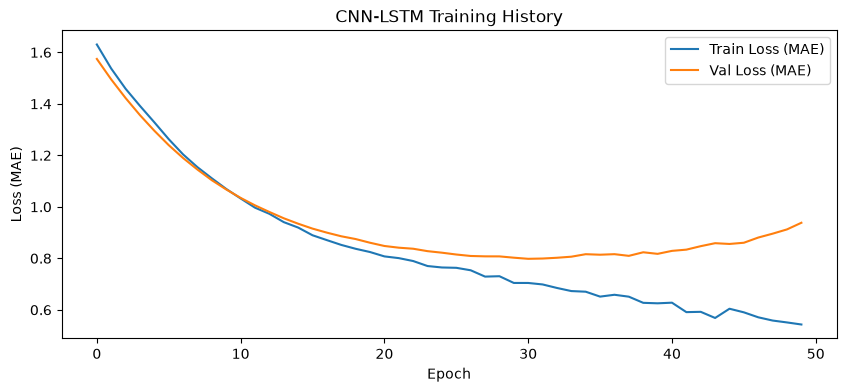

In [7]:
# 모델 생성, 학습 및 평가 수행
hybrid_model = build_and_train_hybrid_model(X_train, X_test, y_train, y_test)

In [8]:
import joblib

# 1. 모델 저장 (.keras 형식)
hybrid_model.save("nasdaq_cnn_lstm.keras")

# 2. 스케일러 저장 (.pkl 형식)
joblib.dump(scaler, "nasdaq_scaler.pkl")

print("모델 및 스케일러 저장 완료")

모델 및 스케일러 저장 완료
